# 27. Ограничения из знаний о предметной области: монотонность и запрет взаимодействий

| | |
|---|---|
| **Уровень** | 4 из 4 — большие данные и сложные задачи (`4_large`) |
| **Скрипт-источник** | [`27_monotone_and_interaction_constraints.py`](../27_monotone_and_interaction_constraints.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 6 с |

**Цель.** Встроить в модель то, что известно заранее, — модель становится объяснимее и устойчивее к шуму.

### Чему вы научитесь

- `monotone_constraints`: цена не убывает с площадью и не растёт с удалённостью
- Проверка монотонности на сетке
- `interaction_constraints`: какие признаки могут встречаться в одной ветви дерева
- Проверка запрета через значения взаимодействий SHAP
- Цена ограничений на малых и больших данных

### Данные

`_data.make_houses` — 2000 (мало, шумно) и 20 000 квартир; цель — `log(цены)`.

### План

1. **Этап 1.** Данные (категории — кодами, чтобы ограничения задавались по номерам столбцов)
2. **Этап 2.** Без ограничений, 2000 квартир: как часто модель нарушает очевидное
3. **Этап 3.** monotone_constraints: +1 для площади, −1 для расстояния
4. **Этап 4.** interaction_constraints: признаки квартиры и признаки места не смешиваются в одной ветви
5. **Этап 5.** Цена ограничений при разном объёме данных (RMSE на одном тесте)
6. **Этап 6.** Выводы

> Ноутбук собран из `examples/4_large/27_monotone_and_interaction_constraints.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_houses

ex = Example(EXAMPLES / "4_large/27_monotone_and_interaction_constraints.py", title="27. Монотонность и запрет взаимодействий",
             goal="встроить знания о предметной области в модель")

import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from gbcourse.style import ROLE

## Этап 1. Данные (категории — кодами, чтобы ограничения задавались по номерам столбцов)

In [2]:
X_all, price_all = make_houses(ex.size(24_000, 8000), seed=27)
X_all = X_all.assign(район=X_all["район"].cat.codes, ремонт=X_all["ремонт"].cat.codes)
y_all = np.log(price_all)
ex.describe(X_all, y_all, target="log(цена)", source="examples/_data.py → make_houses")
cols = list(X_all.columns)
te = np.arange(len(y_all) - 4000, len(y_all))                # последние 4000 — общий тест
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
MONO = {"площадь": 1, "до_центра_км": -1}
mono = tuple(MONO.get(c, 0) for c in cols)


def fit(n_train, **kw):
    idx = np.arange(n_train)
    m = xgb.XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=0, **kw)
    return m.fit(X_all.iloc[idx], y_all[idx])


def violations(model, col, n_obj=200):
    """Доля объектов, у которых прогноз хоть раз идёт «не в ту сторону» при изменении одного признака."""
    grid = np.linspace(X_all[col].quantile(0.02), X_all[col].quantile(0.98), 40)
    sign, bad = MONO[col], 0
    for i in te[:n_obj]:
        Z = X_all.iloc[[i] * len(grid)].copy()
        Z[col] = grid
        d = np.diff(model.predict(Z)) * sign
        bad += bool((d < -1e-9).any())
    return bad / n_obj

   Источник: examples/_data.py → make_houses
   Объектов: 24 000   признаков: 10   память: 1.51 МБ
   Типы признаков: int64 × 5, float64 × 3, int8 × 2
   Пропуски: кухня 5.0%
   Цель «log(цена)»: среднее 2.066, σ 0.473, мин -0.059, макс 3.462
   Первые строки:


,площадь,комнаты,этаж,этажность,год,до_центра_км,район,парковка,ремонт,кухня,[log(цена)]
0,36.9,1,3,5,2009,3.12,8,0,2,7.0,2.140889
1,97.7,5,8,9,2008,7.78,1,0,3,18.4,2.817383
2,23.3,1,6,9,1979,21.85,0,0,2,5.0,0.788003


## Этап 2. Без ограничений, 2000 квартир: как часто модель нарушает очевидное

In [3]:
free = fit(2000)
for c in MONO:
    print(f"   «{c}»: нарушение у {violations(free, c):.0%} объектов")
ex.note("""Хотя бы маленький «провал» есть почти у каждого объекта: модель подгоняется под шум, и где-то прибавка площади
«удешевляет» квартиру. Покупателю и регулятору это не объяснить.""")

   «площадь»: нарушение у 100% объектов


   «до_центра_км»: нарушение у 100% объектов


> ▸ **Вывод.** Хотя бы маленький «провал» есть почти у каждого объекта: модель подгоняется под шум, и где-то прибавка площади «удешевляет» квартиру. Покупателю и регулятору это не объяснить.

## Этап 3. monotone_constraints: +1 для площади, −1 для расстояния

   «площадь»: нарушение у 0% объектов


   «до_центра_км»: нарушение у 0% объектов
   RMSE на тесте: без ограничений 0.1108, с ограничениями 0.1087


   самый глубокий «провал» по площади без ограничения: 5.0% цены; медианный по квартирам: 1.9%


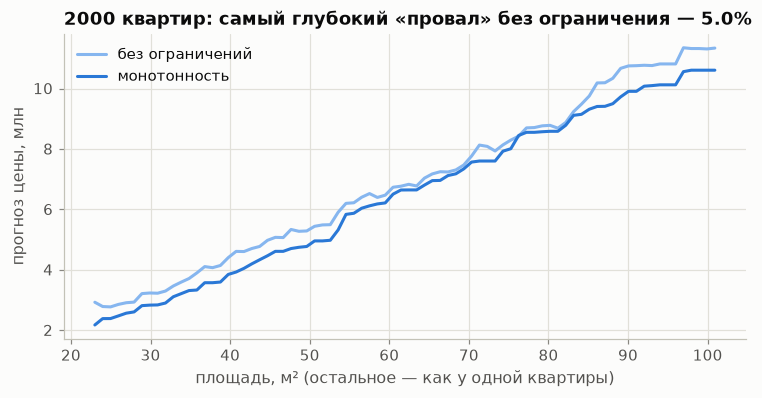

In [4]:
mono_m = fit(2000, monotone_constraints=mono)
for c in MONO:
    v = violations(mono_m, c)
    print(f"   «{c}»: нарушение у {v:.0%} объектов")
    assert v == 0
print(f"   RMSE на тесте: без ограничений {rmse(y_all[te], free.predict(X_all.iloc[te])):.4f}, "
      f"с ограничениями {rmse(y_all[te], mono_m.predict(X_all.iloc[te])):.4f}")

area = np.linspace(X_all["площадь"].quantile(0.02), X_all["площадь"].quantile(0.98), 80)
dips = []
for i in te[:200]:                                           # квартира с самым глубоким «провалом» без ограничения
    Z = X_all.iloc[[i] * len(area)].copy()
    Z["площадь"] = area
    dips.append((-np.diff(free.predict(Z))).max())
print(f"   самый глубокий «провал» по площади без ограничения: {100 * max(dips):.1f}% цены; "
      f"медианный по квартирам: {100 * np.median(dips):.1f}%")
Z = X_all.iloc[[te[int(np.argmax(dips))]] * len(area)].copy()
Z["площадь"] = area
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(area, np.exp(free.predict(Z)), color=ROLE["model_prev"], lw=2, label="без ограничений")
ax.plot(area, np.exp(mono_m.predict(Z)), color=ROLE["model"], lw=2, label="монотонность")
ax.set(xlabel="площадь, м² (остальное — как у одной квартиры)", ylabel="прогноз цены, млн",
       title=f"2000 квартир: самый глубокий «провал» без ограничения — {100 * max(dips):.1f}%")
ax.legend()
ex.finish(fig, "27_monotone_curve")

## Этап 4. interaction_constraints: признаки квартиры и признаки места не смешиваются в одной ветви

In [5]:
FLAT = ["площадь", "комнаты", "этаж", "этажность", "ремонт", "кухня", "парковка"]
PLACE = ["год", "до_центра_км", "район"]
groups = [FLAT, PLACE]                                        # для DataFrame XGBoost ждёт имена столбцов
flat, place = [cols.index(c) for c in FLAT], [cols.index(c) for c in PLACE]
inter_m = fit(2000, interaction_constraints=groups)
booster = inter_m.get_booster()
iv = booster.predict(xgb.DMatrix(X_all.iloc[te[:500]]), pred_interactions=True)
cross = np.abs(iv[:, flat][:, :, place]).mean(0).max()
inside = np.abs(iv[:, place][:, :, place]).mean(0)
np.fill_diagonal(inside, 0)
print(f"   наибольшее взаимодействие «квартира × место»: {cross:.1e} (запрещено — должно быть 0)")
print(f"   наибольшее взаимодействие внутри группы «место»: {inside.max():.4f} (разрешено: год × расстояние)")
print(f"   RMSE на тесте: {rmse(y_all[te], inter_m.predict(X_all.iloc[te])):.4f}")
assert cross < 1e-6
ex.note("""Истинная цена = площадь × цена_м²(место) × множители: в логарифме группы складываются, поэтому запрет
соответствует истине и не мешает, а на малых данных помогает (этап 5). Модель — сумма частей «квартира» + «место».""")

   наибольшее взаимодействие «квартира × место»: 0.0e+00 (запрещено — должно быть 0)
   наибольшее взаимодействие внутри группы «место»: 0.0129 (разрешено: год × расстояние)
   RMSE на тесте: 0.1090


> ▸ **Вывод.** Истинная цена = площадь × цена\_м²(место) × множители: в логарифме группы складываются, поэтому запрет соответствует истине и не мешает, а на малых данных помогает (этап 5). Модель — сумма частей «квартира» + «место».

## Этап 5. Цена ограничений при разном объёме данных (RMSE на одном тесте)

In [6]:
print("   обучающих      без ограничений   монотонность   + запрет взаимодействий")
for n_tr in (500, 2000, len(y_all) - 4000):
    a = rmse(y_all[te], fit(n_tr).predict(X_all.iloc[te]))
    b = rmse(y_all[te], fit(n_tr, monotone_constraints=mono).predict(X_all.iloc[te]))
    c = rmse(y_all[te], fit(n_tr, monotone_constraints=mono, interaction_constraints=groups).predict(X_all.iloc[te]))
    print(f"   {n_tr:9d}      {a:.4f}            {b:.4f}         {c:.4f}")

   обучающих      без ограничений   монотонность   + запрет взаимодействий


         500      0.1752            0.1547         0.1501


        2000      0.1108            0.1087         0.1020


       20000      0.0850            0.0866         0.0848


## Этап 6. Выводы

In [7]:
ex.note("""Верные ограничения — бесплатная регуляризация: на малых данных они помогают, на больших почти не мешают.
Неверные ограничения (если зависимость на самом деле не монотонна) ухудшают модель — проверяйте их на валидации.""")
ex.done()

> ▸ **Вывод.** Верные ограничения — бесплатная регуляризация: на малых данных они помогают, на больших почти не мешают. Неверные ограничения (если зависимость на самом деле не монотонна) ухудшают модель — проверяйте их на валидации.

Готово за 4.7 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Задайте неверное ограничение (цена убывает с площадью) — насколько вырастет RMSE?
2. Почему эффект года (важен только близко к центру) нельзя задать монотонным ограничением?
3. Постройте PDP и ICE по площади для моделей с ограничениями и без.

## Что дальше

- **Теория в курсе:** [12.3 «PDP, ICE, монотонность»](../../../lessons/lesson_12_3/README.md), [7.3 «Сложность и штрафы»](../../../lessons/lesson_7_3/README.md).
- **Предыдущий пример:** [26. Интервалы прогноза: квантильный бустинг и конформная калибровка (CQR)](26_prediction_intervals.ipynb)
- **Следующий пример:** [28. Калибровка вероятностей: когда «70%» действительно означает 70%](28_probability_calibration.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)